# Photonic Crystal Band-Gap Filtering

This notebook models a one-dimensional photonic crystal as a periodic finite-difference wave operator with alternating refractive-index contrast. The alternating medium opens spectral gaps.

A QSVT-style Gaussian spectral window selects modes near one photonic band while suppressing modes in the neighboring band.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from qsvt.matrix_functions import design_gaussian_window_polynomial
from qsvt.pde import periodic_laplacian_1d
from qsvt.polynomials import eval_polynomial
from qsvt.rescaling import rescale_hermitian_to_unit_interval
from qsvt.spectral import apply_polynomial_to_hermitian, eigh_hermitian

np.set_printoptions(precision=4, suppress=True)

In [2]:
n_points = 40
x, laplacian = periodic_laplacian_1d(n_points, length=1.0)
contrast = 38.0
unit_cells = 10
binary_pattern = ((np.arange(n_points) // (n_points // (2 * unit_cells))) % 2).astype(
    float
)
index_potential = contrast * binary_pattern
wave_operator = laplacian + np.diag(index_potential)

evals, evecs = eigh_hermitian(wave_operator)
gaps = np.diff(evals)
gap_index = int(np.argmax(gaps[1:20]) + 1)
lower_band_edge = evals[gap_index]
upper_band_edge = evals[gap_index + 1]
gap_size = upper_band_edge - lower_band_edge

scaled = rescale_hermitian_to_unit_interval(wave_operator)
scaled_evals = np.linalg.eigvalsh(scaled.matrix)
target_energy = lower_band_edge
center = (target_energy - scaled.offset) / scaled.scale
width = 0.035
coeffs = design_gaussian_window_polynomial(center, width, degree=36)
window_operator = apply_polynomial_to_hermitian(scaled.matrix, coeffs)
mode_weights = eval_polynomial(coeffs, scaled_evals)

source = np.exp(-0.5 * ((x - 0.25) / 0.045) ** 2)
filtered_mode = window_operator @ source
filtered_mode = filtered_mode / np.linalg.norm(filtered_mode)

gap_size, target_energy, np.max(mode_weights)

(np.float64(500.45893808166556),
 np.float64(2718.4282533951346),
 np.float64(0.8135833929662374))

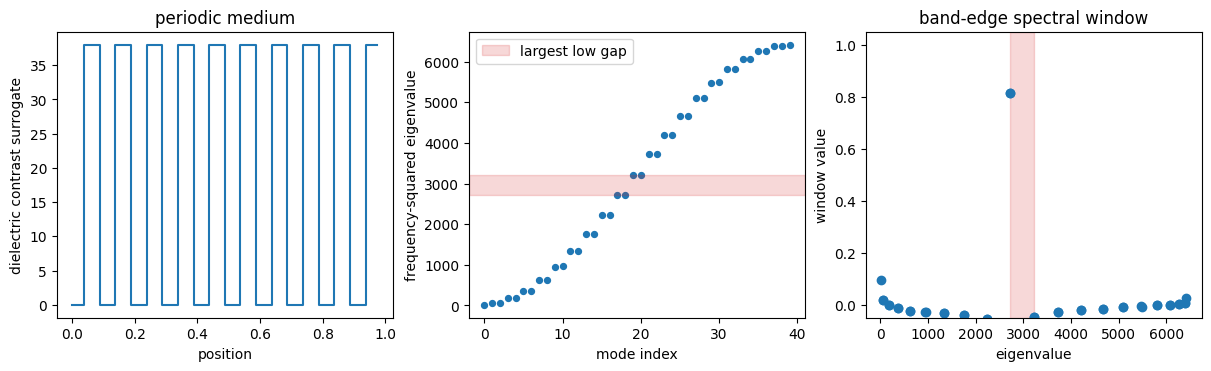

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), constrained_layout=True)

axes[0].step(x, index_potential, where="mid")
axes[0].set_xlabel("position")
axes[0].set_ylabel("dielectric contrast surrogate")
axes[0].set_title("periodic medium")

axes[1].scatter(np.arange(len(evals)), evals, s=18)
axes[1].axhspan(
    lower_band_edge,
    upper_band_edge,
    color="tab:red",
    alpha=0.18,
    label="largest low gap",
)
axes[1].set_xlabel("mode index")
axes[1].set_ylabel("frequency-squared eigenvalue")
axes[1].legend()

axes[2].plot(evals, mode_weights, "o")
axes[2].axvspan(lower_band_edge, upper_band_edge, color="tab:red", alpha=0.18)
axes[2].set_xlabel("eigenvalue")
axes[2].set_ylabel("window value")
axes[2].set_ylim(-0.05, 1.05)
axes[2].set_title("band-edge spectral window")

plt.show()

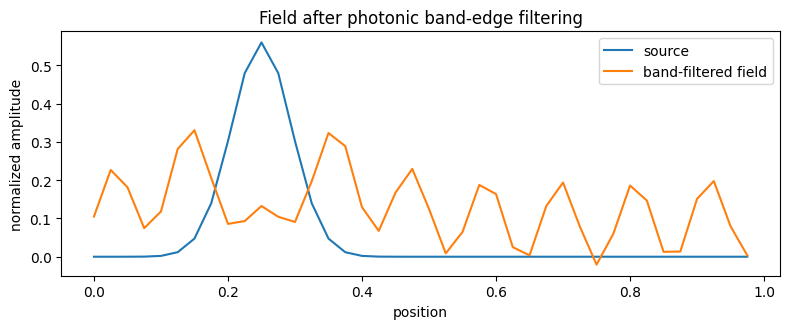

In [4]:
plt.figure(figsize=(8, 3.4))
plt.plot(x, source / np.linalg.norm(source), label="source")
plt.plot(x, filtered_mode, label="band-filtered field")
plt.xlabel("position")
plt.ylabel("normalized amplitude")
plt.title("Field after photonic band-edge filtering")
plt.legend()
plt.tight_layout()
plt.show()

In [5]:
assert gap_size > 10.0
assert np.max(mode_weights) > 0.7
assert np.sum(mode_weights > 0.25) <= 4
assert np.isclose(np.linalg.norm(filtered_mode), 1.0)

print(f"selected_gap_index: {gap_index}")
print(f"gap_size: {gap_size:.3f}")
print(f"max_window_weight: {np.max(mode_weights):.3f}")
print("validation: passed")

selected_gap_index: 18
gap_size: 500.459
max_window_weight: 0.814
validation: passed
